# B5 - Chance nodes: the backgammon bridge

raccoon's distinctive challenge vs chess/Go AlphaZero is **dice**. The fix is simple
and elegant: at a *chance node* the search **samples an outcome and skips it** - the
network is never evaluated on a dice roll. Decision nodes are where planning happens.

We use `DiceRace`: a tiny race where each turn you roll a die (chance node) then
choose which checker to advance (decision node). It's small enough to **solve
exactly**, so we can again check the learned value against ground truth.

In [1]:
import numpy as np, torch
from azl.games.dice_race import DiceRace
from azl.mcts import MCTS, advance_through_chance

s = DiceRace.start()
print("start is a chance node:", s.is_chance())
print("dice outcomes:", s.chance_outcomes())          # uniform over the die faces
s = advance_through_chance(s, np.random.default_rng(0))  # the REAL roll
print("after rolling ->", s.render())
print("legal moves (which checker to advance):", s.legal_actions())

start is a chance node: True
dice outcomes: [(1, 0.3333333333333333), (2, 0.3333333333333333), (3, 0.3333333333333333)]
after rolling -> P0 pips=(6, 6) off=0 | P1 pips=(6, 6) off=0 | to_move=P0 die=2
legal moves (which checker to advance): [6]


In [2]:
# MCTS plans through chance nodes internally (sampling dice during look-ahead).
torch.manual_seed(0)
from azl.network import net_for_game
net = net_for_game(DiceRace)
mcts = MCTS(net, num_simulations=120, rng=np.random.default_rng(0))
vp, root_value, vc = mcts.search(s)
print("visit policy over moves:", {a: round(p, 2) for a, p in vp.items()})
print("root value:", round(root_value, 2))

visit policy over moves: {6: 1.0}
root value: -0.01


value MAE vs solver: 0.134


optimal-move accuracy: 0.895


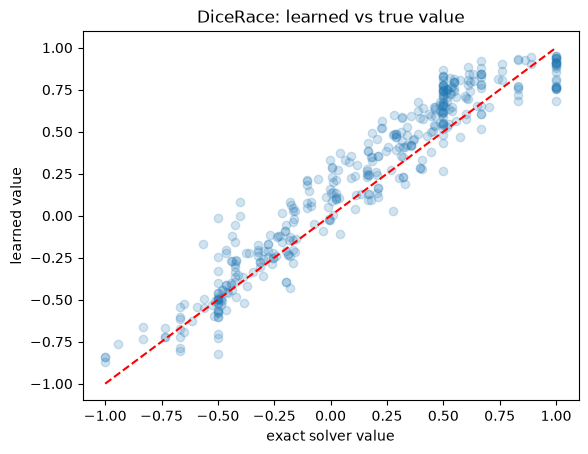

In [3]:
# Train, then compare the learned VALUE to the exact solver value.
import matplotlib.pyplot as plt
from azl.trainer import Coach, CoachConfig
from azl.solvers import ExactSolver, enumerate_states
from azl.metrics import value_mae_vs_solver, optimal_action_accuracy
from azl.evaluate import mcts_player

torch.manual_seed(0)
coach = Coach(net=net_for_game(DiceRace), game_cls=DiceRace,
              config=CoachConfig(games_per_iter=20, num_simulations=40, temp_threshold=4), seed=0)
coach.train(20, verbose=False)

solver = ExactSolver()
states = enumerate_states(DiceRace.start())
sample = [states[i] for i in np.random.default_rng(1).choice(len(states), 400, replace=False)]
learned = [coach.net.predict(st.encode(), st.legal_actions())[1] for st in sample]
exact = [solver.value(st) for st in sample]
print("value MAE vs solver:", round(value_mae_vs_solver(coach.net, sample, solver), 3))
print("optimal-move accuracy:", round(optimal_action_accuracy(
    mcts_player(coach.net, 40, rng=np.random.default_rng(2)), sample, solver), 3))

plt.scatter(exact, learned, alpha=0.2); plt.plot([-1, 1], [-1, 1], "r--")
plt.xlabel("exact solver value"); plt.ylabel("learned value"); plt.title("DiceRace: learned vs true value"); plt.show()

### What to notice
The search handled dice without ever evaluating the network at a roll, and the value
head lines up well with the exact solver (points hug the diagonal).

### Maps to raccoon
`advance_through_chance` and the chance branch of `MCTS._simulate` are the toy of
raccoon's `_advance_through_chance`. The encoding even carries a normalised die value,
like raccoon's dice channels. **What we left out:** real backgammon has *hitting* and
*contact* (your move depends on the opponent's blots), which is what makes raccoon's
position distribution rich - and hard. DiceRace's independent races are the gentle
first step.